# Inspeção de Qualidade

## 1. Conhecendo o Dataset

### Classes
- `def_front`: peças defeituosas
- `ok_front`: peças em perfeito estado

### Formato das imagens
- `.jpeg`

### Quantidade de imagens
- `def_front`: 781 imagens
- `ok_front`: 519 imagens
- Total: 1.300 imagens

### Observações visuais
As peças da classe `def_front` apresentam irregularidades como partes
tortas, buracos e riscos. As peças da classe `ok_front` não apresentam
essas irregularidades visíveis.

### Amostras selecionadas

**Imagem A:** `cast_ok_0_9658.jpeg`  
Classe: `ok_front`  
Motivo: peça em perfeito estado utilizada como referência.

**Imagem B:** `cast_def_0_122.jpeg`  
Classe: `def_front`  
Motivo: apresenta defeito claramente visível.

**Imagem C:** `cast_def_0_9643.jpeg`  
Classe: `def_front`  
Motivo: apresenta defeito mais discreto.

As quantidades acima correspondem ao arquivo `casting_512x512.zip` utilizado
neste projeto. O código também confere as quantidades encontradas nas pastas.

## 2. Configuração do ambiente

Execute as células de cima para baixo, com o kernel reiniciado. Utilize Python 3.12
e as bibliotecas indicadas na célula abaixo. Se precisar instalá-las, retire o `#`
da linha `%pip`, execute a instalação e reinicie o kernel.

### 2.1 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para carregar,
processar e visualizar as imagens, construir a CNN e salvar seus resultados.

In [1]:
# Execute somente se as bibliotecas ainda não estiverem instaladas:
# %pip install "tensorflow>=2.16,<2.22" "opencv-python>=4.9,<6" "matplotlib>=3.8,<4" "numpy>=1.26,<3"

import json
import zipfile
from pathlib import Path, PurePosixPath

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 123
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
EPOCHS = 20
CLASS_NAMES = ["def_front", "ok_front"]  # 0 = Defeituosa; 1 = OK.
NOMES_CLASSES = ["Defeituosa", "OK"]
LIMIAR_CLASSIFICACAO = 0.5
CANNY_MIN, CANNY_MAX = 30, 100

keras.utils.set_random_seed(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 11})
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.21.0
OpenCV: 5.0.0


### 2.2 Localização do dataset e pasta de resultados

É mantida a organização `dataset/casting_512x512/def_front` e
`dataset/casting_512x512/ok_front`. O notebook procura essas pastas no diretório
atual e no diretório acima. Se encontrar o ZIP ao lado do notebook, dentro de
`dataset` ou em `Downloads`, extrai somente as imagens das duas classes.

Se o dataset estiver em outro local, preencha `PASTA_DATASET` ou `ARQUIVO_ZIP`
com um `Path`. Os gráficos, o histórico e o modelo serão salvos em `resultados`.

In [2]:
PASTA_DATASET = None  # Exemplo: Path(r"C:/meu_projeto/dataset/casting_512x512")
ARQUIVO_ZIP = None  # Exemplo: Path(r"C:/meu_projeto/casting_512x512.zip")

pasta_atual = Path.cwd()
raiz_projeto = pasta_atual
if PASTA_DATASET is not None:
    diretorio_dataset = Path(PASTA_DATASET).expanduser().resolve()
else:
    candidatos = [
        base / relativo
        for base in [pasta_atual, pasta_atual.parent]
        for relativo in ["dataset/casting_512x512", "casting_512x512"]
    ]
    diretorio_dataset = next(
        (p for p in candidatos if all((p / c).is_dir() for c in CLASS_NAMES)), None
    )
    if diretorio_dataset is None:
        arquivos_zip = (
            [Path(ARQUIVO_ZIP).expanduser()] if ARQUIVO_ZIP is not None else [
                pasta_atual / "casting_512x512.zip",
                pasta_atual / "dataset" / "casting_512x512.zip",
                Path.home() / "Downloads" / "casting_512x512.zip",
            ]
        )
        arquivo_zip = next((p for p in arquivos_zip if p.is_file()), None)
        if arquivo_zip is None:
            raise FileNotFoundError(
                "Dataset não encontrado. Preencha PASTA_DATASET ou ARQUIVO_ZIP "
                "na primeira linha desta célula."
            )
        destino = (pasta_atual / "dataset").resolve()
        with zipfile.ZipFile(arquivo_zip) as arquivo:
            imagens_zip = []
            for item in arquivo.infolist():
                partes = PurePosixPath(item.filename).parts
                if (len(partes) == 3 and partes[0] == "casting_512x512"
                        and partes[1] in CLASS_NAMES
                        and PurePosixPath(item.filename).suffix.lower() in {".jpeg", ".jpg", ".png"}):
                    alvo = (destino / item.filename).resolve()
                    if not alvo.is_relative_to(destino):
                        raise ValueError("O ZIP contém um caminho de imagem inválido.")
                    imagens_zip.append(item)
            if not imagens_zip:
                raise ValueError("O ZIP não contém as pastas de imagens esperadas.")
            destino.mkdir(parents=True, exist_ok=True)
            arquivo.extractall(destino, members=imagens_zip)
        diretorio_dataset = destino / "casting_512x512"
        print("Imagens extraídas:", len(imagens_zip))

if not all((diretorio_dataset / c).is_dir() for c in CLASS_NAMES):
    raise FileNotFoundError(f"Faltam as pastas def_front/ok_front em {diretorio_dataset}")
if diretorio_dataset.parent.name == "dataset":
    raiz_projeto = diretorio_dataset.parent.parent

pasta_resultados = raiz_projeto / "resultados"
pasta_resultados.mkdir(parents=True, exist_ok=True)
print("Dataset:", diretorio_dataset)
print("Resultados:", pasta_resultados)

Dataset: c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\dataset\casting_512x512
Resultados: c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\resultados


## 3. Análise Exploratória com OpenCV

### 3.1 Imagem Original

Inicialmente, a imagem defeituosa é carregada sem alterações para servir
como referência durante o processamento. Dessa forma, será possível
comparar a imagem original com os resultados obtidos nas etapas seguintes.

In [3]:
caminho_imagem = diretorio_dataset / "def_front" / "cast_def_0_122.jpeg"


def carregar_imagem(caminho):
    """Lê imagens inclusive em caminhos com acentos no Windows."""
    caminho = Path(caminho)
    if not caminho.is_file():
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")
    imagem = cv2.imdecode(np.frombuffer(caminho.read_bytes(), dtype=np.uint8), cv2.IMREAD_COLOR)
    if imagem is None:
        raise ValueError(f"Não foi possível decodificar a imagem: {caminho}")
    return imagem


imagem_bgr = carregar_imagem(caminho_imagem)
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
print("Imagem:", caminho_imagem.name)
print("Formato (altura, largura, canais):", imagem_bgr.shape)

Imagem: cast_def_0_122.jpeg
Formato (altura, largura, canais): (512, 512, 3)


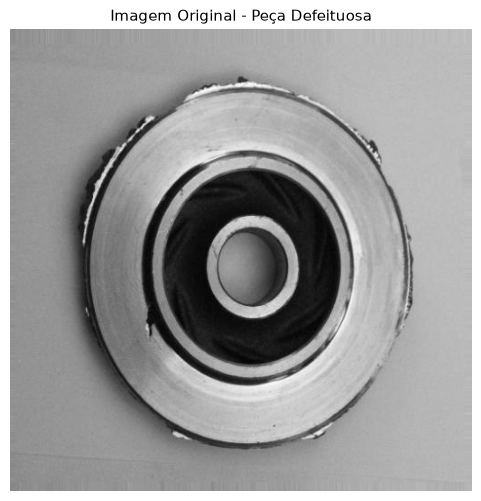

In [4]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_rgb)

plt.title("Imagem Original - Peça Defeituosa")

plt.axis("off")

plt.show()

### 3.2 Conversão para Grayscale

A imagem foi convertida para escala de cinza com o objetivo de reduzir
a complexidade da informação visual. Nesta representação, o processamento
passa a considerar principalmente as diferenças de intensidade entre os
pixels, facilitando etapas posteriores como limiarização e detecção de bordas.

In [5]:
imagem_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

In [6]:
print("Formato original:", imagem_bgr.shape)
print("Formato grayscale:", imagem_gray.shape)

Formato original: (512, 512, 3)
Formato grayscale: (512, 512)


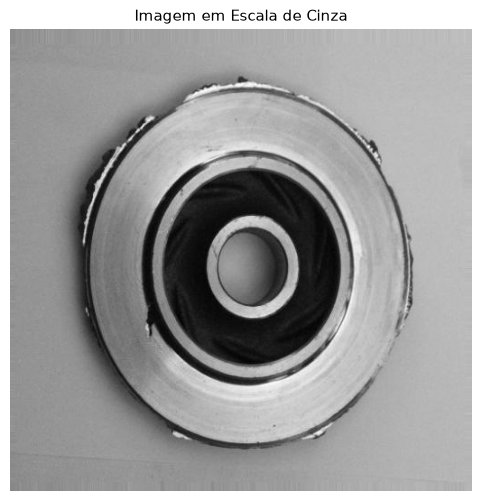

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_gray, cmap="gray")

plt.title("Imagem em Escala de Cinza")

plt.axis("off")

plt.show()

### 3.3 Suavização com Gaussian Blur

Após a conversão para escala de cinza, foi aplicado o Gaussian Blur
para reduzir pequenas variações e ruídos presentes na superfície da imagem.

A suavização é importante porque ruídos podem ser interpretados
incorretamente como bordas nas etapas seguintes. O objetivo é reduzir
esses detalhes sem eliminar as características associadas aos defeitos.

In [8]:
imagem_blur = cv2.GaussianBlur(
    imagem_gray,
    (5, 5),
    0
)

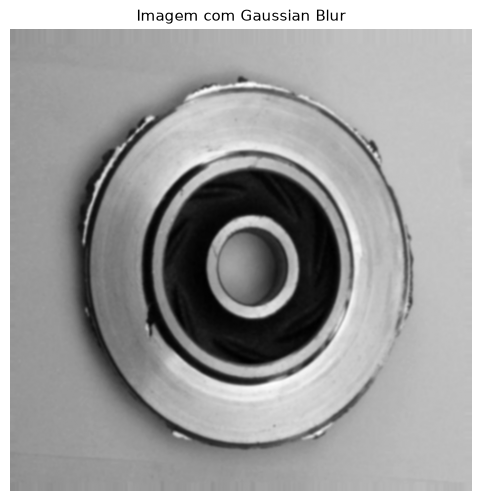

In [9]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_blur, cmap="gray")

plt.title("Imagem com Gaussian Blur")

plt.axis("off")

plt.show()

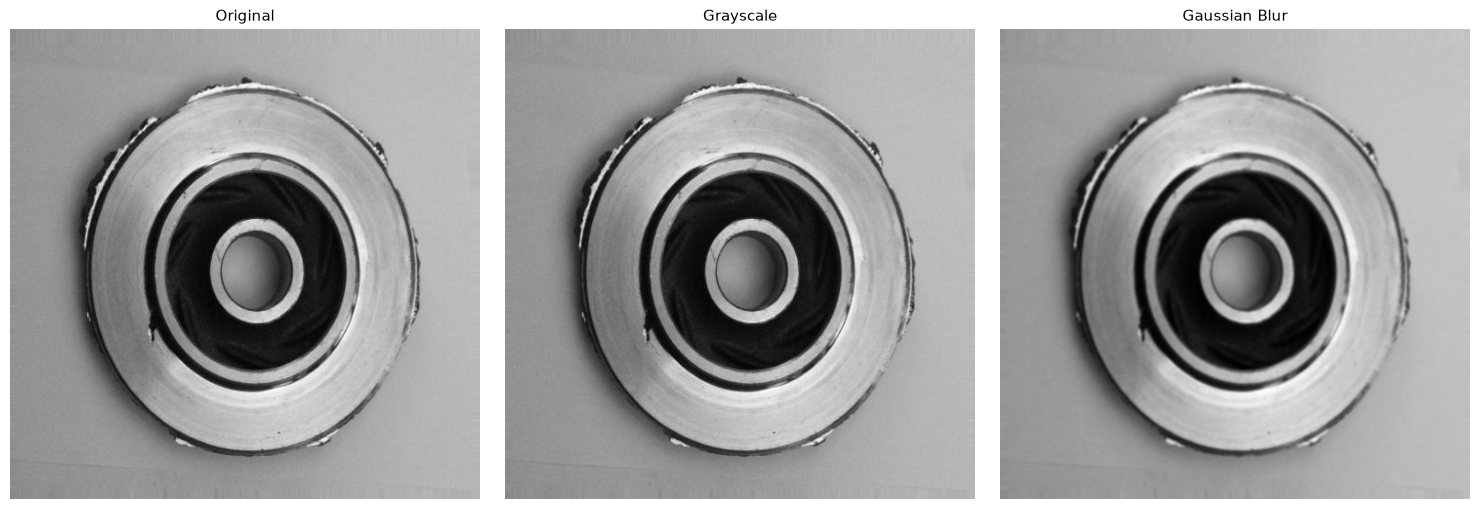

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagem_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(imagem_blur, cmap="gray")
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Observação do resultado

Após a conversão para escala de cinza, os detalhes de intensidade da
superfície permaneceram visíveis. Com a aplicação do Gaussian Blur,
pequenas variações da textura foram suavizadas, enquanto o defeito
principal da peça continuou perceptível.

In [11]:
blur_3 = cv2.GaussianBlur(imagem_gray, (3, 3), 0)
blur_5 = cv2.GaussianBlur(imagem_gray, (5, 5), 0)
blur_7 = cv2.GaussianBlur(imagem_gray, (7, 7), 0)

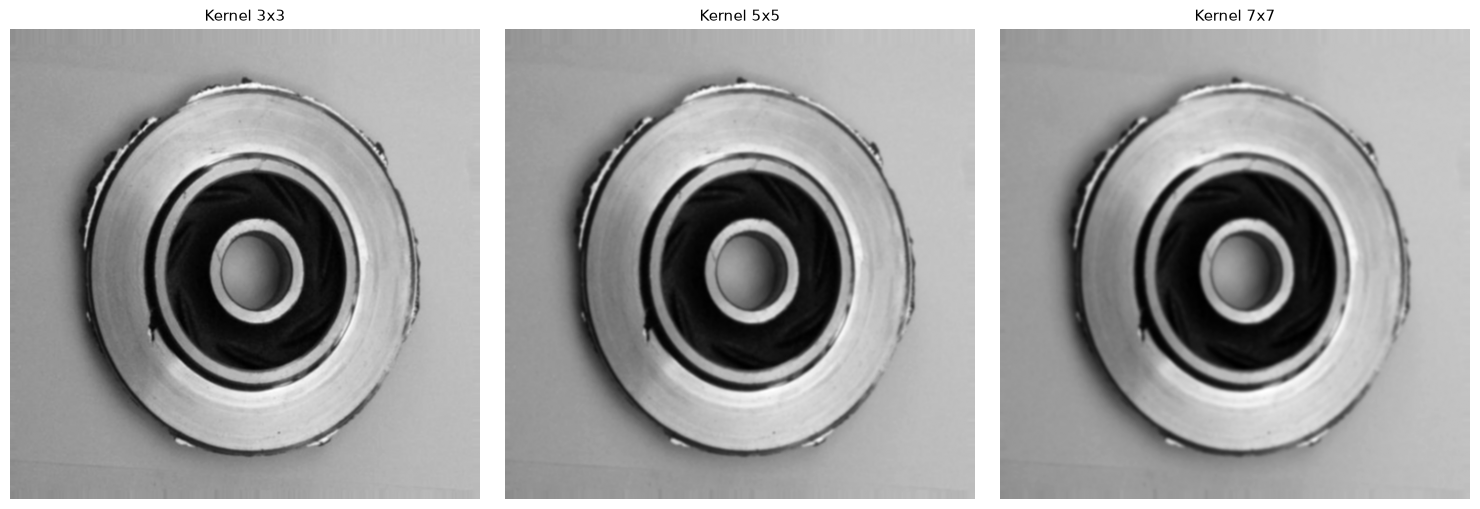

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(blur_3, cmap="gray")
axes[0].set_title("Kernel 3x3")
axes[0].axis("off")

axes[1].imshow(blur_5, cmap="gray")
axes[1].set_title("Kernel 5x5")
axes[1].axis("off")

axes[2].imshow(blur_7, cmap="gray")
axes[2].set_title("Kernel 7x7")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# PNG preserva os pixels do processamento sem compressão com perdas.
for nome, imagem in {"defeito_grayscale": imagem_gray, "defeito_gaussian_blur": imagem_blur}.items():
    sucesso, png = cv2.imencode(".png", imagem)
    if not sucesso:
        raise OSError(f"Não foi possível salvar {nome}.")
    (pasta_resultados / f"{nome}.png").write_bytes(png.tobytes())

## 4. Destaque de Características

Nesta etapa serão utilizadas técnicas de limiarização, detecção de bordas
e operações morfológicas com o objetivo de evidenciar irregularidades
presentes na superfície da peça.

### 4.1 Limiarização

São comparados um limite manual, o método automático de Otsu e a versão
invertida. A limiarização separa intensidades; regiões claras ou escuras
também podem pertencer à geometria normal da peça.

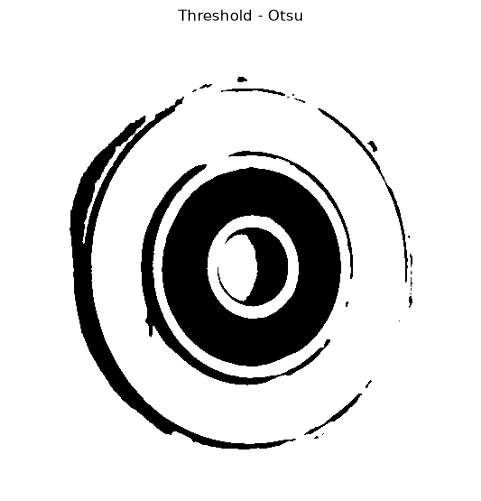

In [14]:
_, threshold_otsu = cv2.threshold(
    imagem_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold_otsu, cmap="gray")
plt.title("Threshold - Otsu")
plt.axis("off")
plt.show()

In [15]:
valor_limite = 120

_, imagem_threshold = cv2.threshold(
    imagem_blur,
    valor_limite,
    255,
    cv2.THRESH_BINARY
)

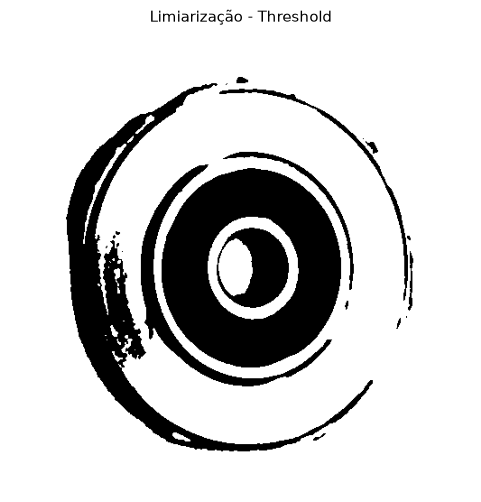

In [16]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_threshold, cmap="gray")
plt.title("Limiarização - Threshold")
plt.axis("off")

plt.show()

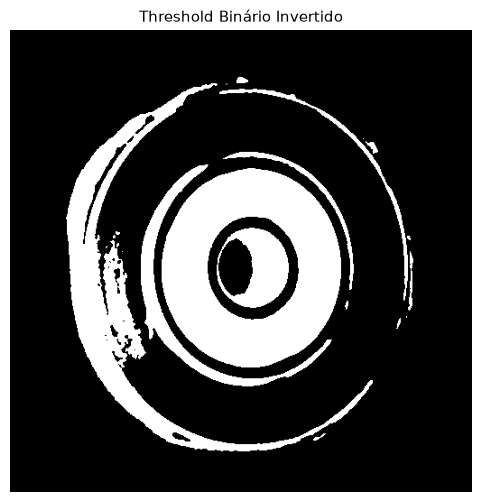

In [17]:
_, threshold_invertido = cv2.threshold(
    imagem_blur,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold_invertido, cmap="gray")
plt.title("Threshold Binário Invertido")
plt.axis("off")
plt.show()

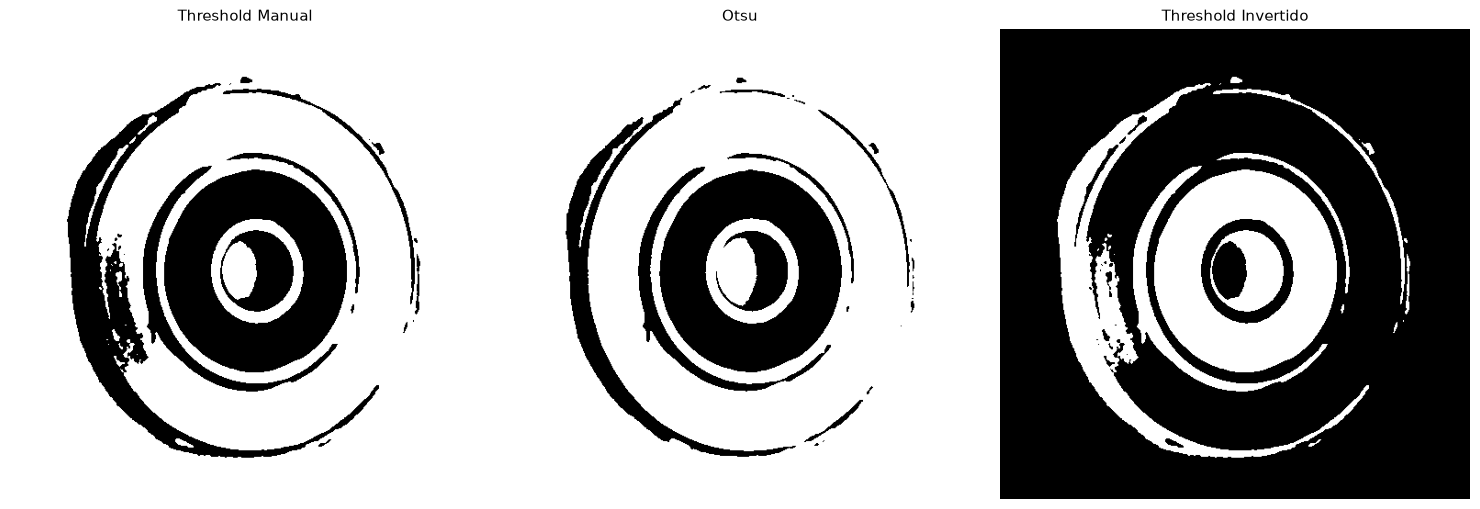

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_threshold, cmap="gray")
axes[0].set_title("Threshold Manual")
axes[0].axis("off")

axes[1].imshow(threshold_otsu, cmap="gray")
axes[1].set_title("Otsu")
axes[1].axis("off")

axes[2].imshow(threshold_invertido, cmap="gray")
axes[2].set_title("Threshold Invertido")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Observações da limiarização
O Threshold manual e o método de Otsu apresentaram resultados semelhantes, evidenciando principalmente as regiões estruturais da peça. A limiarização não conseguiu isolar claramente os defeitos, pois as variações naturais de intensidade e a geometria circular também foram destacadas. Por esse motivo, a próxima etapa utilizará detecção de bordas para tentar evidenciar melhor riscos, buracos e irregularidades.

### 4.2 Detecção de bordas com Canny

Primeiro é mostrado o Canny com limiares 50 e 150. Depois são comparadas três
configurações. Os limiares 30 e 100 são mantidos nas etapas seguintes, de
acordo com a análise exploratória original.

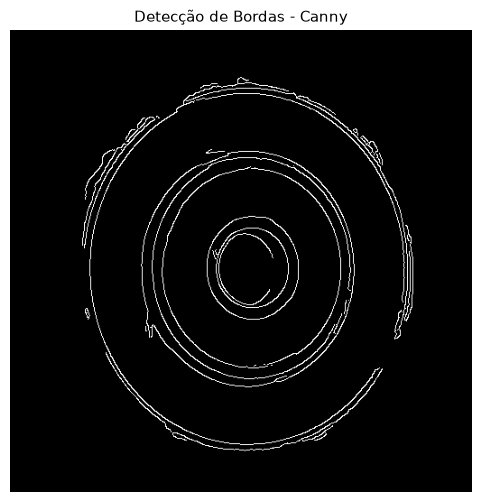

In [19]:
imagem_canny = cv2.Canny(
    imagem_blur,
    50,
    150
)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_canny, cmap="gray")
plt.title("Detecção de Bordas - Canny")
plt.axis("off")
plt.show()

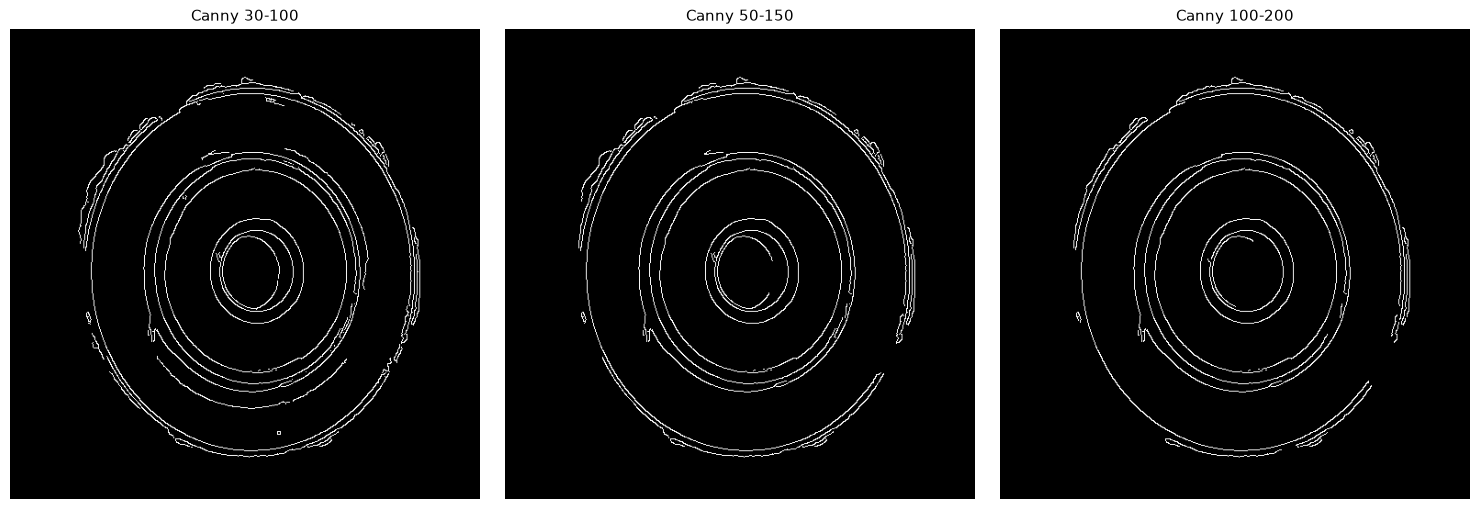

In [20]:
canny_30_100 = cv2.Canny(imagem_blur, 30, 100)
canny_50_150 = cv2.Canny(imagem_blur, 50, 150)
canny_100_200 = cv2.Canny(imagem_blur, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(canny_30_100, cmap="gray")
axes[0].set_title("Canny 30-100")
axes[0].axis("off")

axes[1].imshow(canny_50_150, cmap="gray")
axes[1].set_title("Canny 50-150")
axes[1].axis("off")

axes[2].imshow(canny_100_200, cmap="gray")
axes[2].set_title("Canny 100-200")
axes[2].axis("off")

plt.tight_layout()
plt.show()

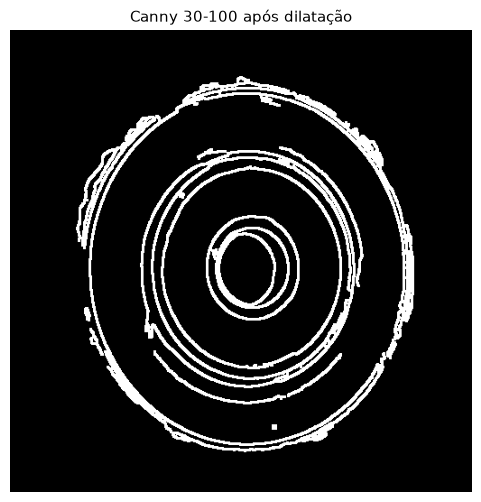

In [21]:
# Utiliza de fato a configuração indicada nos próximos gráficos.
imagem_canny = cv2.Canny(imagem_blur, CANNY_MIN, CANNY_MAX)
kernel = np.ones((3, 3), dtype=np.uint8)
imagem_dilatada = cv2.dilate(imagem_canny, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_dilatada, cmap="gray")
plt.title("Canny 30-100 após dilatação")
plt.axis("off")
plt.show()

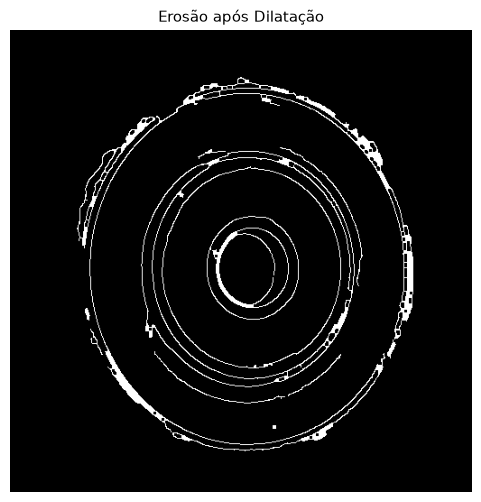

In [22]:
imagem_erodida = cv2.erode(
    imagem_dilatada,
    kernel,
    iterations=1
)

plt.figure(figsize=(6, 6))

plt.imshow(imagem_erodida, cmap="gray")
plt.title("Erosão após Dilatação")
plt.axis("off")

plt.show()

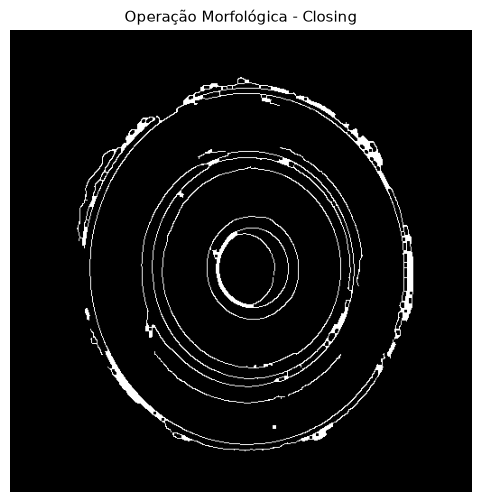

In [23]:
imagem_closing = cv2.morphologyEx(
    imagem_canny,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)
plt.figure(figsize=(6, 6))

plt.imshow(imagem_closing, cmap="gray")
plt.title("Operação Morfológica - Closing")
plt.axis("off")

plt.show()

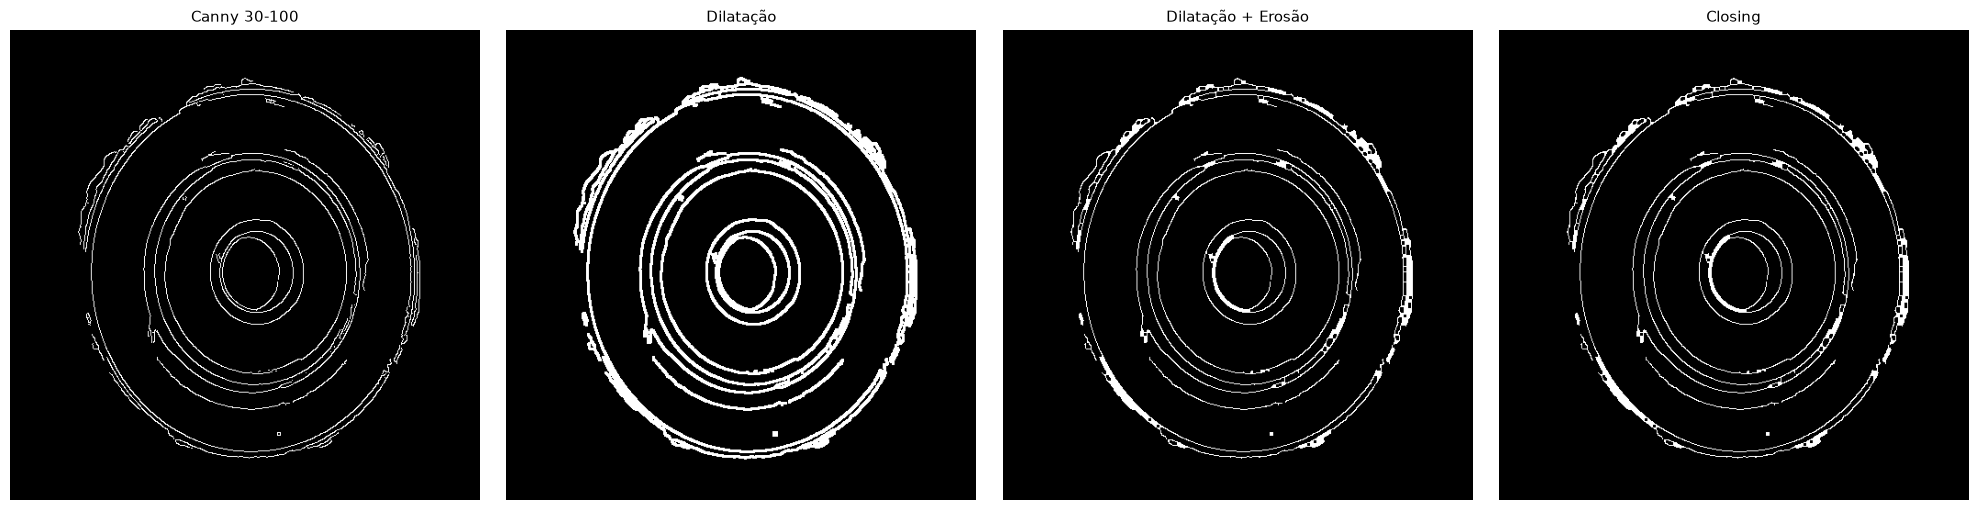

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(imagem_canny, cmap="gray")
axes[0].set_title("Canny 30-100")
axes[0].axis("off")

axes[1].imshow(imagem_dilatada, cmap="gray")
axes[1].set_title("Dilatação")
axes[1].axis("off")

axes[2].imshow(imagem_erodida, cmap="gray")
axes[2].set_title("Dilatação + Erosão")
axes[2].axis("off")

axes[3].imshow(imagem_closing, cmap="gray")
axes[3].set_title("Closing")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 4.3 Operações Morfológicas

Após a detecção de bordas com Canny, são aplicadas operações morfológicas
para conectar pequenas interrupções e reforçar os contornos.

A dilatação torna as bordas mais espessas. A erosão aplicada depois reduz
esse espessamento. A sequência de dilatação seguida de erosão constitui
o Closing quando utiliza o mesmo kernel e as mesmas condições.
Por isso, as duas últimas imagens devem apresentar resultados equivalentes.
O Closing com kernel 3x3 é mantido como operação principal do pipeline.

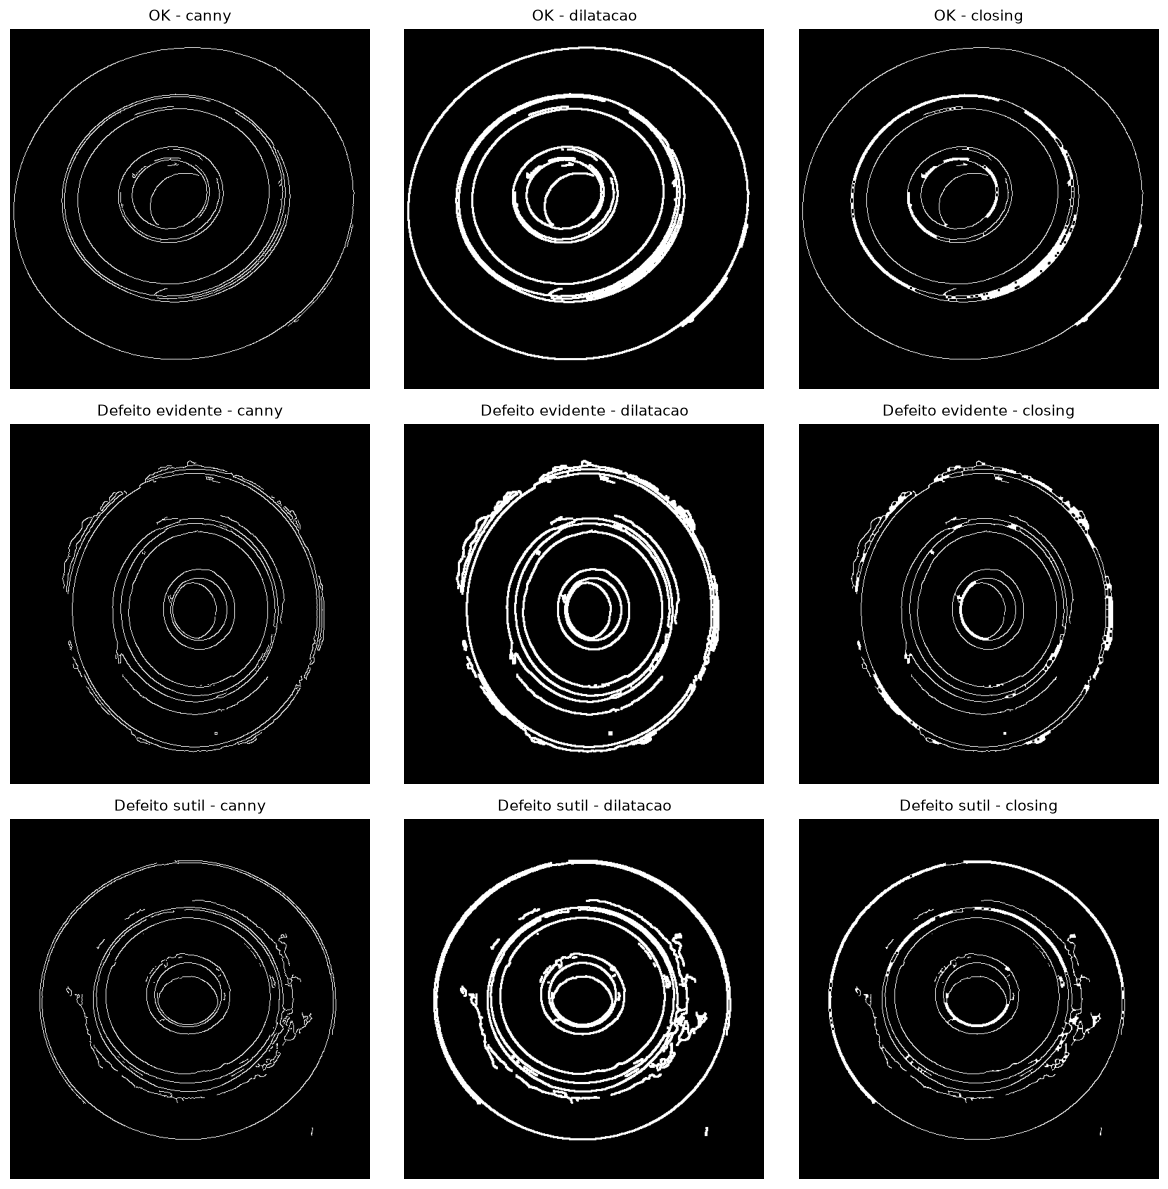

In [25]:
def processar_imagem(caminho):
    """Aplica o mesmo pipeline clássico a cada amostra."""
    bgr = carregar_imagem(caminho)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, threshold = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    canny = cv2.Canny(blur, CANNY_MIN, CANNY_MAX)
    kernel_local = np.ones((3, 3), dtype=np.uint8)
    dilatacao = cv2.dilate(canny, kernel_local, iterations=1)
    erosao = cv2.erode(dilatacao, kernel_local, iterations=1)
    closing = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel_local, iterations=1)
    sobreposicao = rgb.copy()
    sobreposicao[closing > 0] = [255, 40, 40]
    return {
        "original": rgb, "gray": gray, "blur": blur, "threshold": threshold,
        "canny": canny, "dilatacao": dilatacao, "erosao": erosao,
        "closing": closing, "sobreposicao": sobreposicao,
    }


pasta_ok = diretorio_dataset / "ok_front"
pasta_def = diretorio_dataset / "def_front"
caminho_ok = pasta_ok / "cast_ok_0_9658.jpeg"
caminho_def_evidente = pasta_def / "cast_def_0_122.jpeg"
caminho_def_sutil = pasta_def / "cast_def_0_9643.jpeg"

resultado_ok = processar_imagem(caminho_ok)
resultado_def_evidente = processar_imagem(caminho_def_evidente)
resultado_def_sutil = processar_imagem(caminho_def_sutil)
resultados = [
    ("OK", resultado_ok),
    ("Defeito evidente", resultado_def_evidente),
    ("Defeito sutil", resultado_def_sutil),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for linha, (nome, resultado) in enumerate(resultados):
    for coluna, etapa in enumerate(["canny", "dilatacao", "closing"]):
        axes[linha, coluna].imshow(resultado[etapa], cmap="gray")
        axes[linha, coluna].set_title(f"{nome} - {etapa}")
        axes[linha, coluna].axis("off")
plt.tight_layout()
plt.savefig(pasta_resultados / "comparacao_morfologia.png", bbox_inches="tight")
plt.show()

### Conclusão da etapa de morfologia

Após comparar as operações morfológicas nas três amostras selecionadas,
o Closing apresentou o resultado mais equilibrado.

Na peça sem defeito, a estrutura das bordas permaneceu relativamente
organizada. Já nas peças defeituosas, o Closing ajudou a conectar pequenas
descontinuidades e tornar algumas irregularidades mais evidentes.

Por esse motivo, o Closing com kernel 3x3 foi escolhido como a operação
morfológica principal do pipeline de análise exploratória.

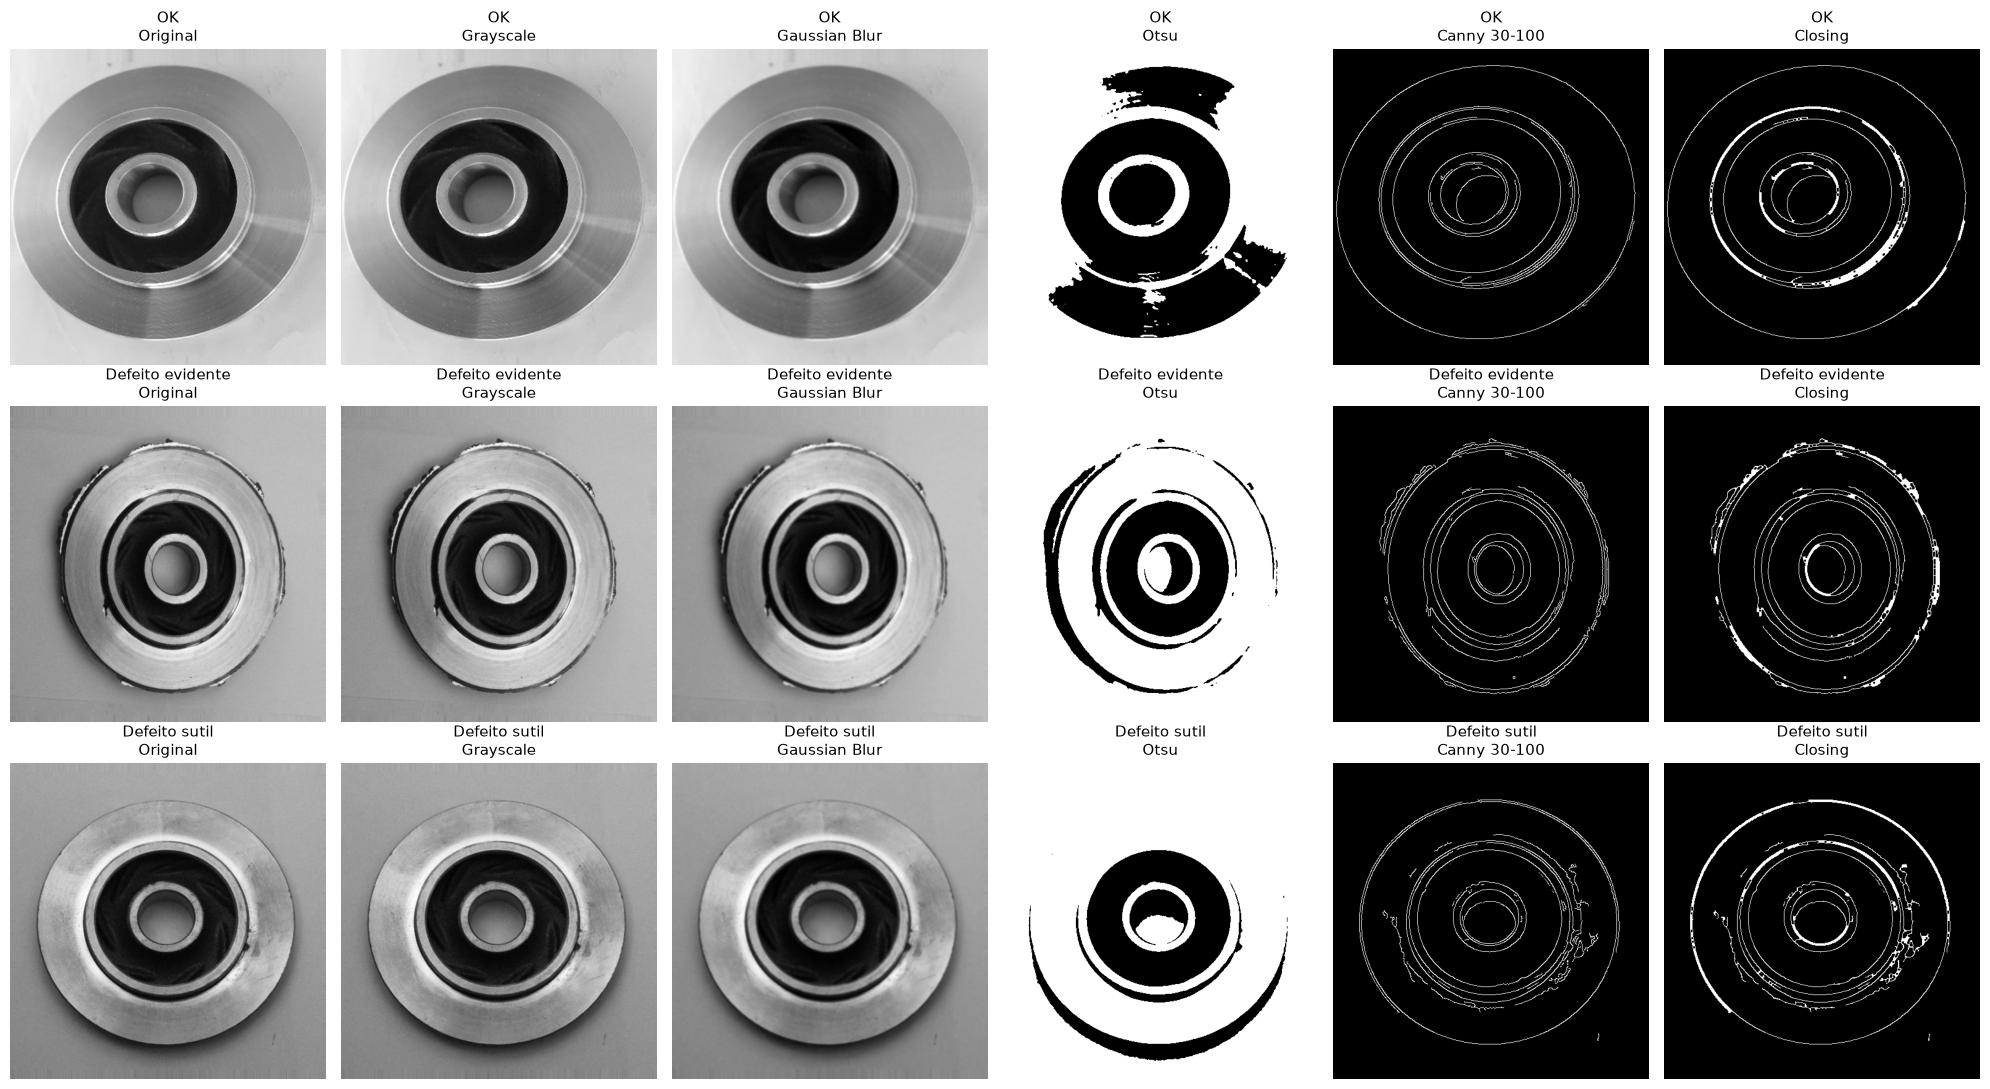

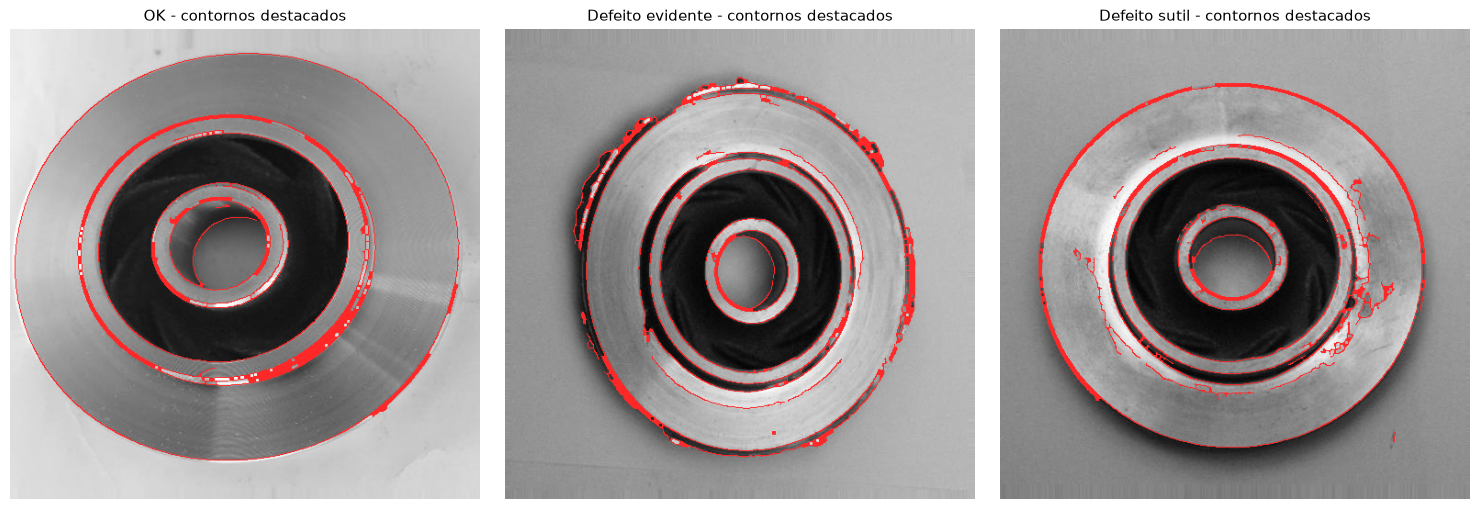

In [26]:
etapas = [
    ("original", "Original"), ("gray", "Grayscale"), ("blur", "Gaussian Blur"),
    ("threshold", "Otsu"), ("canny", "Canny 30-100"), ("closing", "Closing"),
]
fig, axes = plt.subplots(3, len(etapas), figsize=(20, 11))
for linha, (nome, resultado) in enumerate(resultados):
    for coluna, (chave, titulo) in enumerate(etapas):
        axes[linha, coluna].imshow(resultado[chave], cmap="gray")
        axes[linha, coluna].set_title(f"{nome}\n{titulo}")
        axes[linha, coluna].axis("off")
plt.tight_layout()
plt.savefig(pasta_resultados / "pipeline_opencv.png", bbox_inches="tight")
plt.show()

# Sobrepõe as bordas para facilitar a inspeção na imagem original.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nome, resultado) in zip(axes, resultados):
    ax.imshow(resultado["sobreposicao"])
    ax.set_title(f"{nome} - contornos destacados")
    ax.axis("off")
plt.tight_layout()
plt.savefig(pasta_resultados / "contornos_sobrepostos.png", bbox_inches="tight")
plt.show()

### Conclusão da análise exploratória com OpenCV

O pré-processamento permitiu observar como diferentes técnicas respondem
às características das peças.

A conversão para escala de cinza simplificou a informação visual, enquanto
o Gaussian Blur reduziu pequenas variações da superfície.

A limiarização conseguiu separar regiões de intensidade, porém não isolou
claramente os defeitos devido à própria geometria da peça.

A detecção de bordas com Canny apresentou melhores resultados utilizando
os limiares 30 e 100. Por fim, o Closing ajudou a conectar pequenas
descontinuidades nas bordas e apresentou o comportamento mais consistente
entre as amostras analisadas.

O destaque em vermelho representa os contornos encontrados pelo pipeline,
incluindo bordas normais da peça. Ele auxilia a análise visual, mas não é uma
máscara de defeitos confirmados. As três amostras têm finalidade exploratória;
a avaliação quantitativa da CNN utiliza a divisão de dados da próxima etapa.

## 5. Carregamento do Dataset e Data Augmentation

Nesta etapa, o dataset completo será carregado automaticamente com
TensorFlow/Keras e dividido em conjuntos de treinamento e validação.

Também serão aplicadas técnicas de Data Augmentation para simular
variações que podem ocorrer durante uma inspeção industrial.

In [27]:
extensoes = {".jpeg", ".jpg", ".png", ".bmp", ".gif"}
imagens_por_classe = {
    classe: sorted(p for p in (diretorio_dataset / classe).rglob("*")
                   if p.is_file() and p.suffix.lower() in extensoes)
    for classe in CLASS_NAMES
}
for classe, caminhos in imagens_por_classe.items():
    if not caminhos:
        raise ValueError(f"A classe {classe} está vazia.")
    print(f"{classe}: {len(caminhos)} imagens")
total_imagens = sum(map(len, imagens_por_classe.values()))
print("Total:", total_imagens)

def_front: 781 imagens
ok_front: 519 imagens
Total: 1300


In [28]:
# Uma única chamada cria as duas partes da mesma divisão aleatória.
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    diretorio_dataset,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=SEED,
    shuffle=True,
    class_names=CLASS_NAMES,
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
class_names = list(train_ds.class_names)
arquivos_treino = list(train_ds.file_paths)
arquivos_validacao = list(val_ds.file_paths)
if set(arquivos_treino) & set(arquivos_validacao):
    raise ValueError("Há arquivos compartilhados entre treino e validação.")
if len(arquivos_treino) + len(arquivos_validacao) != total_imagens:
    raise ValueError("A divisão não incluiu todas as imagens contadas.")

for nome, arquivos in [("Treino", arquivos_treino), ("Validação", arquivos_validacao)]:
    contagem = {classe: sum(Path(p).is_relative_to(diretorio_dataset / classe)
                           for p in arquivos) for classe in class_names}
    if not all(contagem.values()):
        raise ValueError(f"{nome} não contém exemplos das duas classes: {contagem}")
    print(f"{nome}: {len(arquivos)} imagens | {contagem}")
print("Rótulos:", dict(enumerate(class_names)))

divisao = {
    nome: [str(Path(p).relative_to(diretorio_dataset)) for p in arquivos]
    for nome, arquivos in [("treino", arquivos_treino), ("validacao", arquivos_validacao)]
}
(pasta_resultados / "divisao_dados.json").write_text(
    json.dumps(divisao, ensure_ascii=False, indent=2), encoding="utf-8"
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Using 260 files for validation.
Treino: 1040 imagens | {'def_front': 620, 'ok_front': 420}
Validação: 260 imagens | {'def_front': 161, 'ok_front': 99}
Rótulos: {0: 'def_front', 1: 'ok_front'}


49553

### Divisão dos dados

São usados 80% dos arquivos para treino e 20% para validação, com semente fixa.
As duas classes têm sua presença conferida em cada conjunto. A divisão é
aleatória, sem estratificação automática; as contagens acima permitem verificá-la.
O arquivo `divisao_dados.json` registra quais imagens foram utilizadas.

`label_mode="binary"` produz rótulos com formato `(lote, 1)`, compatível com a
saída da rede. Com a ordem definida, `0` significa Defeituosa e `1` significa OK.
As métricas de validação ajudam a selecionar o modelo; elas não representam
um teste independente de desempenho em produção.

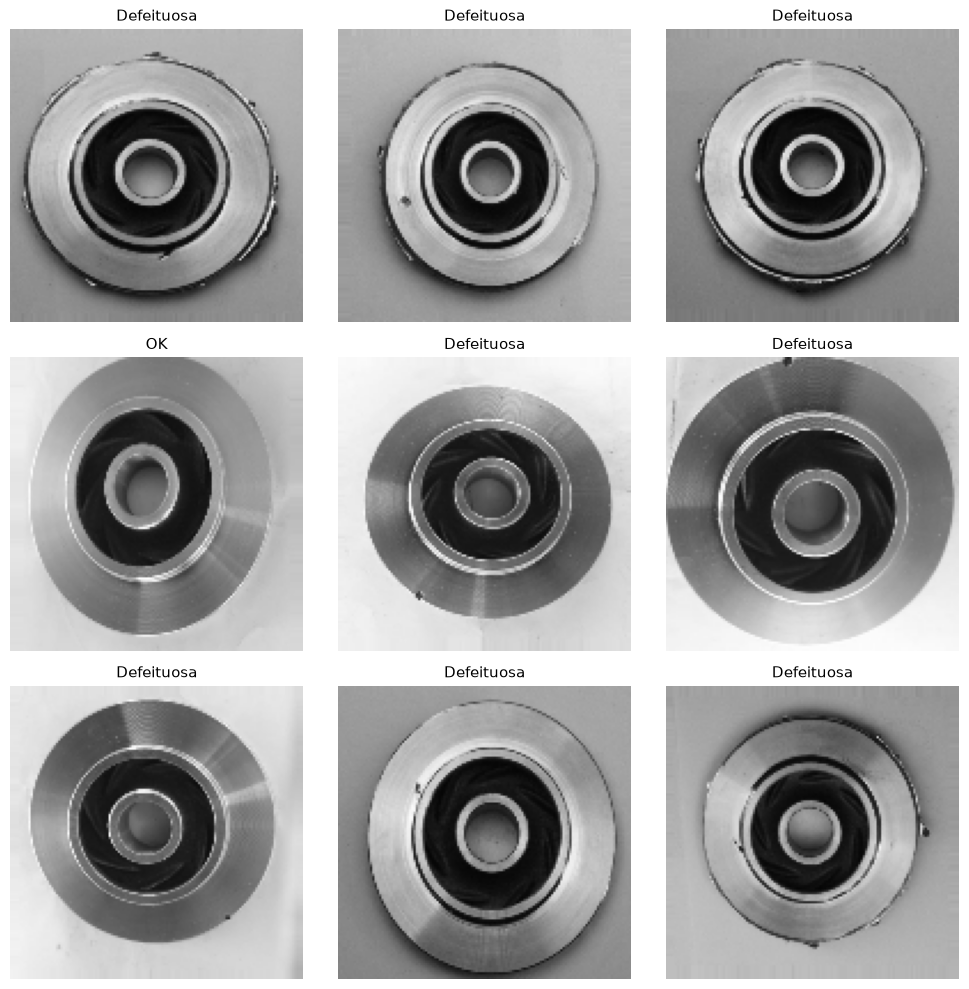

In [29]:
imagens, labels = next(iter(train_ds))
n_amostras = min(9, int(imagens.shape[0]))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.axis("off")
    if i < n_amostras:
        ax.imshow(imagens[i].numpy().astype("uint8"))
        ax.set_title(NOMES_CLASSES[int(labels[i, 0].numpy())])
plt.tight_layout()
plt.show()

### Data Augmentation

Foram aplicadas transformações dinâmicas às imagens de treinamento
para simular pequenas variações que podem ocorrer durante uma inspeção
industrial.

Foram utilizadas alterações geométricas, como rotação, zoom e
deslocamento, além de alterações de luminosidade.

O objetivo é reduzir a dependência do modelo de uma posição ou condição
de iluminação específica e melhorar sua capacidade de generalização.

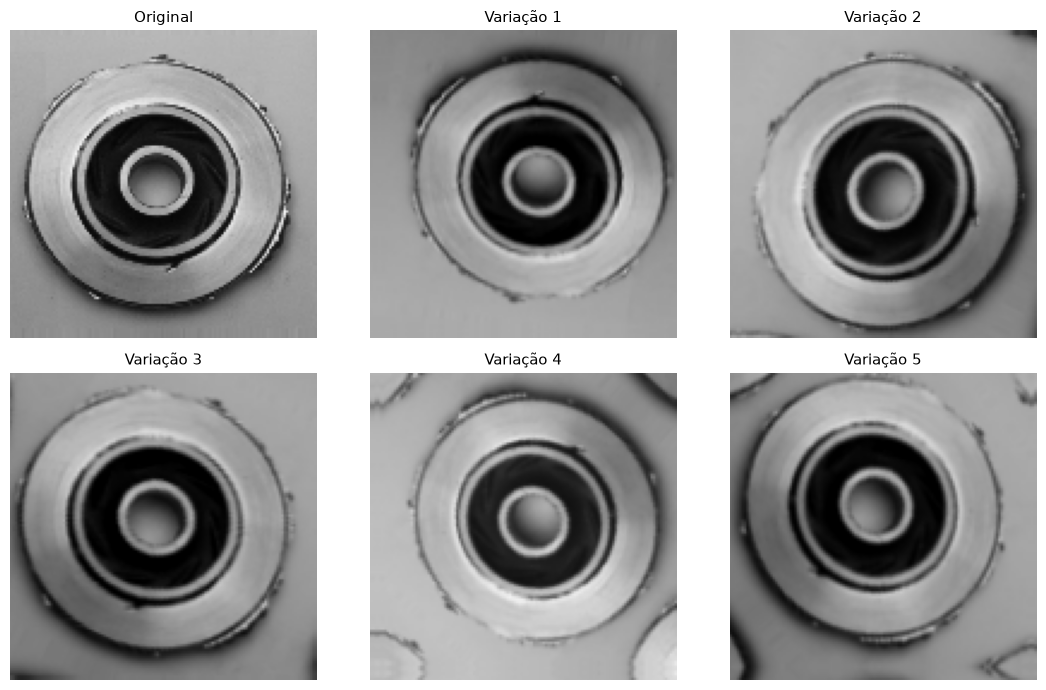

In [30]:
# Os pixels ainda estão na escala [0, 255] nesta etapa.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.2, seed=SEED + 1),
    layers.RandomZoom(0.1, seed=SEED + 2),
    layers.RandomTranslation(0.05, 0.05, seed=SEED + 3),
    layers.RandomBrightness(0.10, value_range=(0, 255), seed=SEED + 4),
], name="data_augmentation")

imagem_exemplo = imagens[:1]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for i, ax in enumerate(axes.flat):
    if i == 0:
        exibida = imagem_exemplo[0]
        titulo = "Original"
    else:
        exibida = data_augmentation(imagem_exemplo, training=True)[0]
        titulo = f"Variação {i}"
    ax.imshow(np.clip(exibida.numpy(), 0, 255).astype("uint8"))
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.savefig(pasta_resultados / "data_augmentation.png", bbox_inches="tight")
plt.show()

As transformações são aplicadas dinamicamente durante o treinamento.
A rotação com fator 0,2 permite até 72 graus em cada sentido, mantendo a
configuração original; o deslocamento é de até 5% e o brilho varia até 10%.
Na validação e nas previsões, o Keras desativa essas camadas aleatórias.
O brilho é alterado antes da normalização para respeitar a escala dos pixels.
As imagens da CNN são as originais redimensionadas, e não as bordas do OpenCV.

## 6. Construção da Rede Neural Convolucional

Nesta etapa será construída uma Rede Neural Convolucional (CNN)
para classificar automaticamente as peças entre as classes
def_front e ok_front.

A arquitetura utilizará camadas Conv2D e MaxPooling2D para extração
de características, seguidas por Flatten e camadas densas para
realizar a classificação binária.

In [31]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

modelo = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30, seed=SEED + 5),
    layers.Dense(1, activation="sigmoid"),
], name="cnn_inspecao_qualidade")

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
)
modelo.summary()

Model: "cnn_inspecao_qualidade"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Explicação do código acima

Performance (AUTOTUNE + prefetch): Carrega os próximos lotes de dados em segundo plano enquanto o modelo treina, reduzindo gargalos de processamento.

Regularização (Data Augmentation + Dropout): Gera variações das imagens de treino e desativa 30% dos neurônios aleatoriamente, ajudando a reduzir o risco de overfitting.

Extração de Características (Conv2D + MaxPooling2D): Identifica padrões visuais (como bordas e texturas) e reduz a dimensão das imagens para otimizar o cálculo.

Classificação Binária (Dense + Sigmoid): Achata os dados (Flatten), processa as características e gera uma estimativa entre 0 e 1 para a classe OK. Valores menores que 0,5 indicam Defeituosa; valores a partir de 0,5 indicam OK.

### Compilação do modelo

O modelo foi compilado utilizando o otimizador Adam e a função de perda
binary_crossentropy, adequada ao problema de classificação binária.

A acurácia foi definida como métrica principal para acompanhar o
desempenho do modelo durante o treinamento.

## 7. Treinamento da CNN

Nesta etapa, o modelo será treinado utilizando o conjunto de treinamento
e acompanhado por meio do conjunto de validação.

Durante o treinamento serão observadas as métricas de Loss e Accuracy,
tanto para treinamento quanto para validação, permitindo posteriormente
avaliar a capacidade de aprendizado e possíveis sinais de overfitting.

In [32]:
caminho_modelo = pasta_resultados / "modelo_inspecao_qualidade.keras"
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=3, restore_best_weights=True, verbose=1
)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(caminho_modelo), monitor="val_loss", mode="min", save_best_only=True
)
registro_csv = keras.callbacks.CSVLogger(str(pasta_resultados / "historico_treinamento.csv"))

historico = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint, registro_csv],
    shuffle=False,  # O próprio train_ds já embaralha as imagens.
    verbose=2,
)

Epoch 1/20
33/33 - 9s - 276ms/step - accuracy: 0.5865 - loss: 0.6831 - val_accuracy: 0.7346 - val_loss: 0.6415
Epoch 2/20
33/33 - 6s - 197ms/step - accuracy: 0.6510 - loss: 0.6285 - val_accuracy: 0.7423 - val_loss: 0.5385
Epoch 3/20
33/33 - 6s - 189ms/step - accuracy: 0.6856 - loss: 0.6016 - val_accuracy: 0.7462 - val_loss: 0.5585
Epoch 4/20
33/33 - 6s - 179ms/step - accuracy: 0.7144 - loss: 0.5851 - val_accuracy: 0.7500 - val_loss: 0.5198
Epoch 5/20
33/33 - 6s - 191ms/step - accuracy: 0.7231 - loss: 0.5595 - val_accuracy: 0.7615 - val_loss: 0.5179
Epoch 6/20
33/33 - 7s - 200ms/step - accuracy: 0.7356 - loss: 0.5511 - val_accuracy: 0.7615 - val_loss: 0.4916
Epoch 7/20
33/33 - 6s - 192ms/step - accuracy: 0.7221 - loss: 0.5489 - val_accuracy: 0.7615 - val_loss: 0.4991
Epoch 8/20
33/33 - 6s - 191ms/step - accuracy: 0.7548 - loss: 0.5168 - val_accuracy: 0.7923 - val_loss: 0.4706
Epoch 9/20
33/33 - 7s - 204ms/step - accuracy: 0.7558 - loss: 0.5088 - val_accuracy: 0.7692 - val_loss: 0.5278
E

In [33]:
acc = historico.history["accuracy"]
val_acc = historico.history["val_accuracy"]
loss = historico.history["loss"]
val_loss = historico.history["val_loss"]
epocas = np.arange(1, len(loss) + 1)

melhor_val_accuracy = max(val_acc)
melhor_epoca_accuracy = int(np.argmax(val_acc)) + 1
melhor_epoca_loss = int(np.argmin(val_loss)) + 1

print(f"Melhor acurácia de validação: {melhor_val_accuracy:.2%} (época {melhor_epoca_accuracy})")
print(f"Modelo salvo: época {melhor_epoca_loss}, menor Val Loss = {min(val_loss):.4f}")
print("Arquivo:", caminho_modelo)

metadados = {
    "classes": class_names, "image_size": list(IMG_SIZE), "seed": SEED,
    "validation_split": VALIDATION_SPLIT, "limiar": LIMIAR_CLASSIFICACAO,
    "saida_sigmoid": "P(OK) estimada pelo modelo",
    "entrada": "RGB na escala [0, 255]; normalização incluída no modelo",
    "epoca_modelo_salvo": melhor_epoca_loss,
    "tensorflow": tf.__version__,
}
(pasta_resultados / "configuracao_modelo.json").write_text(
    json.dumps(metadados, ensure_ascii=False, indent=2), encoding="utf-8"
)
(pasta_resultados / "historico_treinamento.json").write_text(
    json.dumps({k: [float(v) for v in valores] for k, valores in historico.history.items()},
               ensure_ascii=False, indent=2), encoding="utf-8"
)

Melhor acurácia de validação: 80.38% (época 11)
Modelo salvo: época 11, menor Val Loss = 0.4483
Arquivo: c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\resultados\modelo_inspecao_qualidade.keras


1410

O EarlyStopping e o checkpoint utilizam o mesmo critério: a menor perda de
validação. A época de maior acurácia pode ser diferente. A célula seguinte
recarrega o modelo salvo para que a auditoria e as previsões utilizem
exatamente esse arquivo.

In [34]:
modelo = keras.models.load_model(caminho_modelo)

## 8. Auditoria do Treinamento

Nesta etapa será analisado o histórico de treinamento da CNN por meio
das curvas de Loss e Accuracy dos conjuntos de treinamento e validação.

A comparação entre essas métricas permite avaliar a evolução do modelo
e identificar possíveis sinais de overfitting.

In [35]:
val_loss_final, val_accuracy_final = modelo.evaluate(val_ds, verbose=0)
print("Melhor época segundo Val Loss:", melhor_epoca_loss)
print(f"Épocas executadas: {len(loss)}")
print(f"Loss de validação do modelo salvo: {val_loss_final:.4f}")
print(f"Acurácia de validação do modelo salvo: {val_accuracy_final:.2%}")

Melhor época segundo Val Loss: 11
Épocas executadas: 14
Loss de validação do modelo salvo: 0.4483
Acurácia de validação do modelo salvo: 80.38%


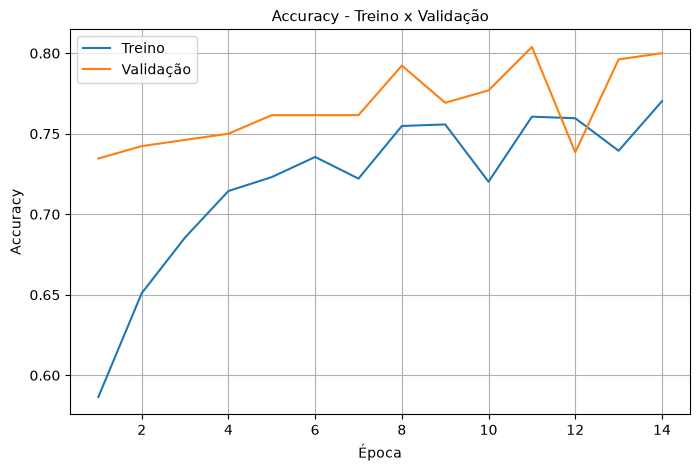

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(epocas, acc, label="Treino")
plt.plot(epocas, val_acc, label="Validação")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy - Treino x Validação")
plt.legend()
plt.grid()

plt.savefig(
    pasta_resultados / "accuracy_treino_validacao.png",
    bbox_inches="tight"
)

plt.show()

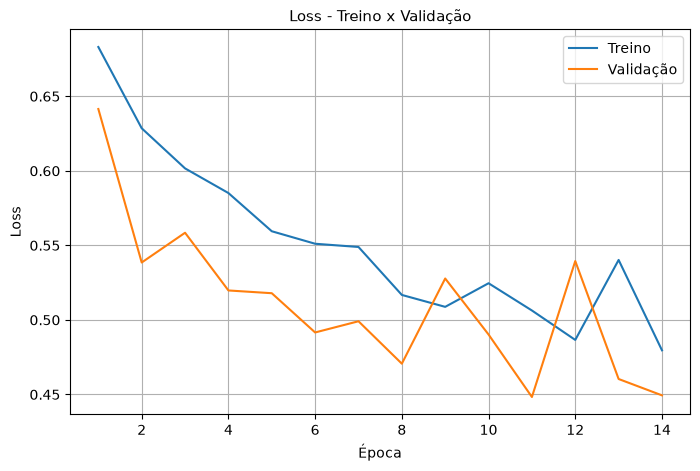

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(epocas, loss, label="Treino")
plt.plot(epocas, val_loss, label="Validação")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - Treino x Validação")
plt.legend()
plt.grid()

plt.savefig(
    pasta_resultados / "loss_treino_validacao.png",
    bbox_inches="tight"
)

plt.show()

### Análise de Overfitting

A interpretação deve considerar os gráficos gerados nesta execução. Quando
a Loss de treino diminui e a Val Loss aumenta por várias épocas, pode haver
sinal de overfitting. Uma diferença persistente entre as acurácias também
merece atenção. Uma oscilação isolada não permite concluir isso.

O EarlyStopping interrompe o treinamento quando a Val Loss deixa de melhorar
pelo período configurado e restaura os melhores pesos. Isso reduz o risco de
continuar ajustando o modelo ao treino, mas não comprova generalização.
Além disso, augmentation e Dropout atuam apenas no treino, de modo que as
duas curvas não são medidas sob condições idênticas.

**Leitura da execução salva:** foram executadas 14 épocas. O modelo da época 11
apresentou a menor Val Loss (0,4483) e 80,38% de acurácia na validação.
As perdas de treino e validação diminuíram no conjunto, com oscilações,
sem um afastamento crescente e persistente nas últimas épocas. Assim,
essas curvas não mostram evidência clara de overfitting acentuado.
Os valores e esta leitura devem ser revistos se o treinamento for executado novamente.


## 9. Teste de Previsões

Após o treinamento, o modelo será utilizado para classificar imagens
do conjunto de validação.

As previsões serão comparadas com as classes reais para verificar
visualmente o comportamento da CNN em peças OK e defeituosas.

In [38]:
imagens_teste, labels_reais = next(iter(val_ds))
previsoes = modelo.predict(imagens_teste, verbose=0).reshape(-1)
classes_previstas = (previsoes >= LIMIAR_CLASSIFICACAO).astype("int32")
labels_numpy = labels_reais.numpy().reshape(-1).astype("int32")

for i in range(min(5, len(previsoes))):
    print(f"P(OK): {previsoes[i]:.4f} | "
          f"Real: {NOMES_CLASSES[labels_numpy[i]]} | "
          f"Previsto: {NOMES_CLASSES[classes_previstas[i]]}")

P(OK): 0.1634 | Real: Defeituosa | Previsto: Defeituosa
P(OK): 0.1246 | Real: Defeituosa | Previsto: Defeituosa
P(OK): 0.0026 | Real: Defeituosa | Previsto: Defeituosa
P(OK): 0.8188 | Real: OK | Previsto: OK
P(OK): 0.5573 | Real: OK | Previsto: OK


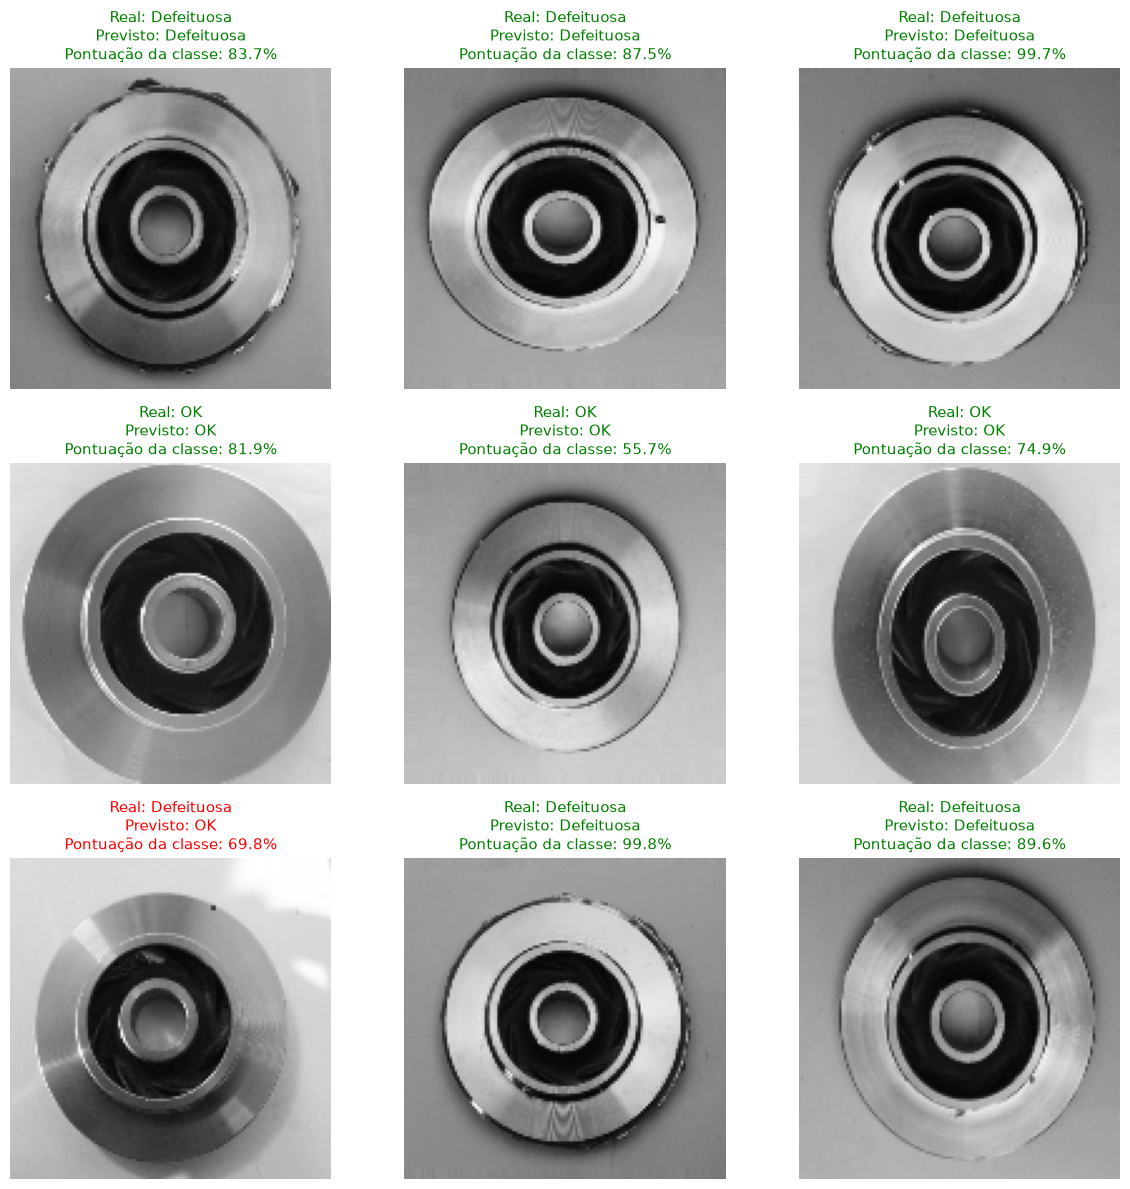

Acertos no lote amostrado: 27/32 (84.38%)


In [39]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.axis("off")
    if i >= min(9, len(previsoes)):
        continue
    indice_previsto = int(classes_previstas[i])
    probabilidade = float(previsoes[i])
    pontuacao = probabilidade if indice_previsto == 1 else 1 - probabilidade
    cor = "green" if indice_previsto == labels_numpy[i] else "red"
    ax.imshow(imagens_teste[i].numpy().astype("uint8"))
    ax.set_title(
        f"Real: {NOMES_CLASSES[labels_numpy[i]]}\n"
        f"Previsto: {NOMES_CLASSES[indice_previsto]}\n"
        f"Pontuação da classe: {pontuacao:.1%}", color=cor
    )
plt.tight_layout()
plt.savefig(pasta_resultados / "previsoes_validacao.png", bbox_inches="tight")
plt.show()

acertos = int(np.count_nonzero(classes_previstas == labels_numpy))
total = len(labels_numpy)
print(f"Acertos no lote amostrado: {acertos}/{total} ({acertos / total:.2%})")

### Avaliação de todo o conjunto de validação

A acurácia do lote acima descreve somente o lote amostrado; até nove imagens são exibidas. A matriz de
confusão a seguir utiliza todas as imagens da validação. Rótulos e previsões
são obtidos juntos, no mesmo lote, para manter a correspondência mesmo com
o embaralhamento do dataset.

O recall da classe Defeituosa mostra a fração de peças defeituosas identificadas.
Na matriz, a linha Defeituosa e a coluna OK mostram os defeitos que passaram
como peças boas. A pontuação da rede não é uma garantia de acerto nem uma
probabilidade calibrada.

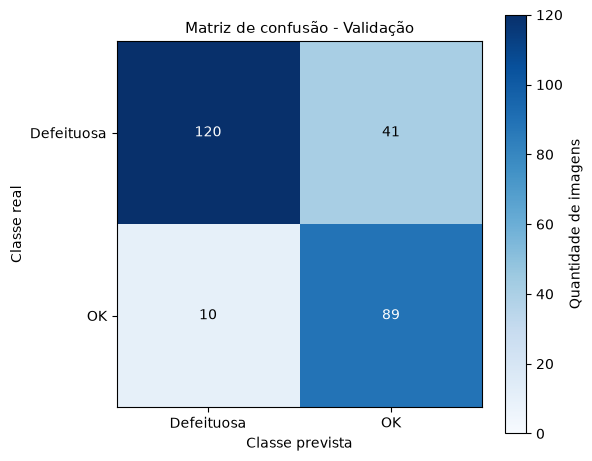

Acurácia em toda a validação: 80.38%
Recall da classe Defeituosa: 74.53%
Precisão da classe Defeituosa: 92.31%
Peças defeituosas previstas como OK: 41


330

In [40]:
rotulos_validacao, predicoes_validacao = [], []
for imagens_lote, labels_lote in val_ds:
    probabilidades_lote = modelo(imagens_lote, training=False).numpy().reshape(-1)
    rotulos_validacao.extend(labels_lote.numpy().reshape(-1).astype("int32"))
    predicoes_validacao.extend((probabilidades_lote >= LIMIAR_CLASSIFICACAO).astype("int32"))

rotulos_validacao = np.asarray(rotulos_validacao)
predicoes_validacao = np.asarray(predicoes_validacao)
matriz = tf.math.confusion_matrix(rotulos_validacao, predicoes_validacao, num_classes=2).numpy()
acuracia_global = float(np.mean(rotulos_validacao == predicoes_validacao))
recall_defeito = float(matriz[0, 0] / matriz[0].sum())
precisao_defeito = float(matriz[0, 0] / matriz[:, 0].sum()) if matriz[:, 0].sum() else 0.0

fig, ax = plt.subplots(figsize=(6, 5))
mapa = ax.imshow(matriz, cmap="Blues", vmin=0)
for linha in range(2):
    for coluna in range(2):
        ax.text(coluna, linha, str(matriz[linha, coluna]), ha="center", va="center",
                color="white" if matriz[linha, coluna] > matriz.max() / 2 else "black")
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=NOMES_CLASSES, yticklabels=NOMES_CLASSES,
       xlabel="Classe prevista", ylabel="Classe real", title="Matriz de confusão - Validação")
fig.colorbar(mapa, ax=ax, label="Quantidade de imagens")
plt.tight_layout()
plt.savefig(pasta_resultados / "matriz_confusao_validacao.png", bbox_inches="tight")
plt.show()

print(f"Acurácia em toda a validação: {acuracia_global:.2%}")
print(f"Recall da classe Defeituosa: {recall_defeito:.2%}")
print(f"Precisão da classe Defeituosa: {precisao_defeito:.2%}")
print(f"Peças defeituosas previstas como OK: {matriz[0, 1]}")
metricas = {
    "quantidade_validacao": len(rotulos_validacao), "loss": float(val_loss_final),
    "accuracy": acuracia_global, "recall_defeito": recall_defeito,
    "precisao_defeito": precisao_defeito, "matriz_confusao": matriz.tolist(),
    "ordem_classes": class_names,
}
(pasta_resultados / "metricas_validacao.json").write_text(
    json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8"
)

### Análise das previsões

O modelo foi testado utilizando imagens do conjunto de validação.
As classes previstas foram comparadas com as classes reais para
avaliar visualmente seu comportamento.

A análise permite identificar tanto classificações corretas quanto
eventuais erros cometidos pela CNN, possibilitando compreender melhor
as limitações do modelo.

Na execução salva, o modelo acertou 209 das 260 imagens da validação:
120 peças defeituosas e 89 peças OK. Entre os erros, 41 peças defeituosas
foram classificadas como OK e 10 peças OK foram classificadas como
defeituosas. Esse resultado mostra por que a acurácia deve ser analisada
junto com os erros por classe, especialmente os defeitos que passaram
como peças boas.


Como a validação também orienta o EarlyStopping, estes resultados descrevem
a auditoria do desenvolvimento. Para estimar o desempenho em novas condições
industriais, seria necessário um conjunto de teste independente, com imagens
de outras peças ou lotes de produção.

## 10. Conclusão

O projeto combinou técnicas de OpenCV e Deep Learning para identificar
defeitos em peças metálicas.

Na análise exploratória, o Grayscale e o Gaussian Blur ajudaram no
pré-processamento, enquanto o Canny com limiares 30 e 100 apresentou
melhor destaque das bordas. Entre as operações morfológicas, o Closing
com kernel 3x3 apresentou o resultado mais equilibrado.

Na etapa de classificação, foi utilizada uma CNN com Data Augmentation,
Conv2D, MaxPooling2D, Flatten, Dense e saída sigmoid.

O modelo alcançou 80,38% de acurácia de validação, com melhor resultado
na época 11. As curvas não indicaram overfitting acentuado, embora ainda
tenham ocorrido erros de classificação.

De forma geral, o projeto atingiu o objetivo de realizar inspeção visual
e classificação automática de peças, apresentando resultados satisfatórios
e possibilidades de melhoria futura.